This Project is a sample for modeling interest rate prediction using a basic MLP neural network using Scikit Learn.  

The data comes from the US Treasury's Daily Treasury Yield found here: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_real_yield_curve&field_tdr_date_value_month=202309

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Read Data

In [ ]:
# Read in the data
interest_rates = pd.read_csv(r"daily-treasury-rates.csv", parse_dates=["Date"])

Review Data

In [3]:
interest_rates.head()

,Date,1 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2023-09-08,5.52,5.56,5.55,5.60,5.49,5.42,4.98,4.68,4.39,4.35,4.26,4.52,4.33
1,2023-09-07,5.52,5.56,5.53,5.59,5.50,5.40,4.94,4.66,4.38,4.35,4.27,4.55,4.36
2,2023-09-06,5.52,5.55,5.55,5.60,5.52,5.44,5.01,4.73,4.44,4.39,4.30,4.56,4.37
3,2023-09-05,5.51,5.56,5.55,5.59,5.51,5.42,4.94,4.65,4.37,4.35,4.27,4.56,4.38
4,2023-09-01,5.51,5.55,5.53,5.58,5.47,5.36,4.87,4.57,4.29,4.27,4.18,4.48,4.29


Drop Missing Values

In [ ]:
interest_rates = interest_rates.dropna(axis=1)

Sort Data

In [ ]:
interest_rates = interest_rates.sort_values(by=["Date"], ascending=True)

Set Lookback Size

In [6]:
lookback_size = 90

Stack Data into Batches

In [ ]:
stacked_rates = (
    interest_rates.iloc[:lookback_size, 1:]
    .to_numpy()
    .reshape(-1, lookback_size, interest_rates.shape[-1] - 1)
)
for i in range(1, len(interest_rates) - lookback_size):
    stacked_rates = np.append(
        stacked_rates,
        interest_rates.iloc[i : i + lookback_size, 1:]
        .to_numpy()
        .reshape(-1, lookback_size, interest_rates.shape[-1] - 1),
        axis=0,
    )

Prepare Data and Outcomes for Modeling

In [ ]:
outcome_rates = interest_rates.iloc[
    lookback_size:, 1:
].to_numpy()  # .reshape(-1, 1, interest_rates.shape[-1] - 1)

In [9]:
stacked_rates = stacked_rates.reshape(outcome_rates.shape[0], -1)

Fit a linear MLP regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100), max_iter=1000, verbose=True, random_state=42
)
model.fit(stacked_rates, outcome_rates)

Iteration 1, loss = 0.63075297
Iteration 2, loss = 0.06620008
Iteration 3, loss = 0.03217431
Iteration 4, loss = 0.02233269
Iteration 5, loss = 0.01710140
Iteration 6, loss = 0.01483538
Iteration 7, loss = 0.01359208
Iteration 8, loss = 0.01205556
Iteration 9, loss = 0.01151105
Iteration 10, loss = 0.01065649
Iteration 11, loss = 0.01186488
Iteration 12, loss = 0.01131676
Iteration 13, loss = 0.00972033
Iteration 14, loss = 0.00862223
Iteration 15, loss = 0.00865605
Iteration 16, loss = 0.00898879
Iteration 17, loss = 0.00769829
Iteration 18, loss = 0.00849712
Iteration 19, loss = 0.00788851
Iteration 20, loss = 0.00711251
Iteration 21, loss = 0.00704197
Iteration 22, loss = 0.00723000
Iteration 23, loss = 0.00636154
Iteration 24, loss = 0.00661860
Iteration 25, loss = 0.00626876
Iteration 26, loss = 0.00619958
Iteration 27, loss = 0.00664597
Iteration 28, loss = 0.00682055
Iteration 29, loss = 0.00542069
Iteration 30, loss = 0.00523043
Iteration 31, loss = 0.00555357
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


Evaluate the performance of the MLP Regressor

In [11]:
model.score(stacked_rates, outcome_rates)

0.9898591951731407

Plot the predictions of the MLP regressor against the actual interest rate data

In [12]:
predictions = model.predict(stacked_rates)

Text(0.5, 1.0, 'Actual vs Predicted Interest Rates')

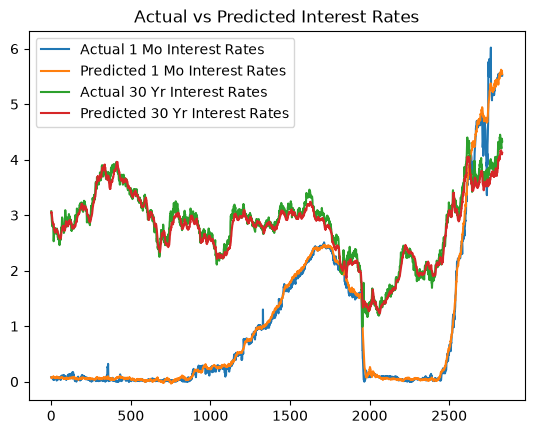

In [13]:
pd.DataFrame(
    {
        "Actual 1 Mo Interest Rates": outcome_rates[:, 0],
        "Predicted 1 Mo Interest Rates": predictions[:, 0],
        "Actual 30 Yr Interest Rates": outcome_rates[:, -1],
        "Predicted 30 Yr Interest Rates": predictions[:, -1],
    }
).plot()
plt.title("Actual vs Predicted Interest Rates")